# 🤖 Comparativa de Modelos de Machine Learning
**Dataset:** Breast Cancer Wisconsin | **Tarea:** Clasificación Binaria

Este notebook compara los principales algoritmos de ML supervisado, evaluando su rendimiento y analizando sus pros y contras.

## 📦 0. Instalación de dependencias

In [211]:
%pip install scikit-learn matplotlib seaborn pandas numpy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\macdu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 📚 1. Mapa de Algoritmos de ML Supervisado

### 🔬 Algoritmos principales ML

| Categoría | Algoritmos incluidos |
|-----------|---------------------|
| **Lineales** | Logistic Regression |
| **Basados en árbol** | Decision Tree, Random Forest, Gradient Boosting |
| **Kernel / Margen** | SVM |
| **Basados en instancias** | KNN |
| **Probabilísticos** | Naive Bayes |
| **Redes neuronales** | MLP Neural Network |

---

### ⚖️ Pros, Contras y Analogía de cada modelo

| Modelo | 🗣️ En una frase | ✅ Pros | ❌ Contras |
|--------|----------------|---------|----------|
| **Logistic Regression** | *"Un semáforo: mide si estás más cerca del rojo o del verde"* | Rápido, interpretable, excelente baseline | Asume linealidad, sensible a outliers |
| **Decision Tree** | *"Un juego de 20 preguntas: ¿tiene más de X mm? ¿es irregular?"* | Muy interpretable, sin escalado | Overfitting fácil, inestable |
| **Random Forest** | *"Pregunta a 100 médicos distintos y vota la mayoría"* | Robusto, maneja overfitting, importancia de features | Lento en predicción, difícil de interpretar |
| **Gradient Boosting** | *"Cada médico aprende de los errores del anterior"* | Alta precisión, muy flexible | Lento de entrenar, muchos hiperparámetros |
| **SVM** | *"Busca la frontera que más separa los dos grupos"* | Muy preciso en datos pequeños/medianos | Lento en datasets grandes, sensible a escala |
| **KNN** | *"Mira tus 7 vecinos más cercanos y copia su diagnóstico"* | Sin entrenamiento, muy intuitivo | Lento en predicción, sensible a ruido |
| **Naive Bayes** | *"Calcula probabilidades asumiendo que todo es independiente"* | Rapidísimo, funciona con pocos datos | Asume independencia entre features |
| **MLP Neural Net** | *"Imita cómo el cerebro conecta neuronas para aprender patrones"* | Captura patrones complejos | Necesita más datos, muchos hiperparámetros |

---

### ⚠️ Confusión frecuente: Logistic Regression NO es regresión

A pesar del nombre, **Logistic Regression es un algoritmo de clasificación**, no de regresión.

| | Logistic Regression | Linear Regression |
|--|--------------------|--------------------|
| **Tarea** | Clasificación | Regresión |
| **Output** | Probabilidad (0 a 1) → clase | Valor numérico continuo |
| **Ejemplo** | ¿Es maligno o benigno? | ¿Cuánto costará una casa? |
| **Función** | Sigmoide | Lineal |

Logistic Regression también funciona en **multiclase** mediante dos estrategias:

| Estrategia | Cómo funciona | Cuándo usarla |
|-----------|--------------|--------------|
| **OvR** (One vs Rest) | Entrena un clasificador binario por cada clase | Clases bien separadas |
| **Multinomial** (Softmax) | Entrena un solo modelo para todas las clases a la vez | Clases solapadas, más preciso |
```python
LogisticRegression(multi_class='ovr')         # One vs Rest
LogisticRegression(multi_class='multinomial') # Softmax
```

---

### 🆚 Bagging vs Boosting — Random Forest vs Gradient Boosting

Ambos usan muchos árboles, pero de forma opuesta:

| | Bagging (Random Forest) | Boosting (Gradient Boosting) |
|--|------------------------|------------------------------|
| **Cómo construye los árboles** | En paralelo, cada uno independiente | En secuencia, cada uno corrige al anterior |
| **Analogía** | 100 médicos opinan a la vez → votan | 100 médicos en cadena → cada uno revisa el caso que el anterior falló |
| **Fortaleza** | Reduce overfitting | Reduce error (más preciso) |
| **Debilidad** | Menos preciso que boosting | Más lento, puede sobreajustar |

---

### 📐 El kernel trick de SVM — sin matemáticas

SVM busca una línea que separe las clases. Pero ¿qué pasa si no son separables linealmente?
```
Sin kernel:          Con kernel (RBF):
   🔴 🔵 🔴             🔴  🔵🔵  🔴
  🔵 🔴 🔵     →    🔴  🔵🔵🔵🔵  🔴
   🔴 🔵 🔴             🔴  🔵🔵  🔴
  (imposible)         (separable en 3D ✅)
```

El kernel "proyecta" los datos a más dimensiones hasta que se pueden separar.
`kernel='rbf'` (por defecto) funciona bien en la mayoría de casos.

---

### 📏 KNN y el efecto de k

El hiperparámetro `n_neighbors` (k) controla todo el comportamiento:
```
k=1  → Overfitting total    — copia al vecino más cercano, memoriza el ruido
k=7  → Balance razonable    — el usado en este notebook
k=N  → Underfitting total   — pregunta a todos, siempre gana la clase mayoritaria
```

> 💡 Regla práctica: empieza con k = √N donde N = número de muestras.
> En este dataset: √455 ≈ 21. El notebook usa 7, que es más agresivo pero funciona bien.

---

## 🧠 2. Overfitting y Underfitting — el problema central de ML

Antes de ver cualquier resultado, hay que entender el problema más importante de ML:
```
         Underfitting          Buen balance          Overfitting
              │                     │                     │
    El modelo es         El modelo aprende        El modelo memoriza
    demasiado simple     los patrones reales      los datos de train
    y no aprende nada    y generaliza bien        y falla en datos nuevos
              │                     │                     │
         Train: bajo           Train: alto           Train: muy alto
         Test:  bajo           Test:  alto           Test:  bajo ⚠️
```

---

**¿Cómo detectarlo?**

| Situación | Train Score | Test Score | Diagnóstico |
|-----------|------------|------------|-------------|
| Train ≈ Test (ambos altos) | ~0.97 | ~0.96 | ✅ Bien — generaliza |
| Train ≈ Test (ambos bajos) | ~0.65 | ~0.63 | ⚠️ Underfitting — modelo demasiado simple |
| Train >> Test | ~0.99 | ~0.75 | 🚨 Overfitting — memoriza, no aprende |

---

**¿Cómo corregirlo según el modelo?**

| Modelo | Corregir Overfitting | Corregir Underfitting |
|--------|---------------------|----------------------|
| Decision Tree | Limitar `max_depth` | Aumentar `max_depth` |
| Random Forest | Reducir `n_estimators` o `max_depth` | Aumentar `n_estimators` |
| Logistic Regression | Aumentar regularización (`C` bajo) | Reducir regularización (`C` alto) |
| KNN | Aumentar `n_neighbors` | Reducir `n_neighbors` |
| MLP | Añadir Dropout, reducir capas | Añadir más capas o neuronas |

> 💡 En este notebook el CV Std te da una pista: si es muy alto,
> el modelo es inestable y probablemente tiene overfitting.

## 🔧 2. Imports

In [212]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, auc, accuracy_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

sns.set_theme(style='whitegrid', palette='muted')
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 🗂️ 3. Carga y Exploración del Dataset

In [213]:
data = load_breast_cancer()
X, y = data.data, data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print(f'📐 Shape del dataset: {X.shape}')
print(f'🏷️  Clases: {dict(zip(data.target_names, np.bincount(y)))}')
print(f'❓ Valores nulos: {df.isnull().sum().sum()}')
df.head(3)

📐 Shape del dataset: (569, 30)
🏷️  Clases: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
❓ Valores nulos: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Maligno
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Maligno
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Maligno


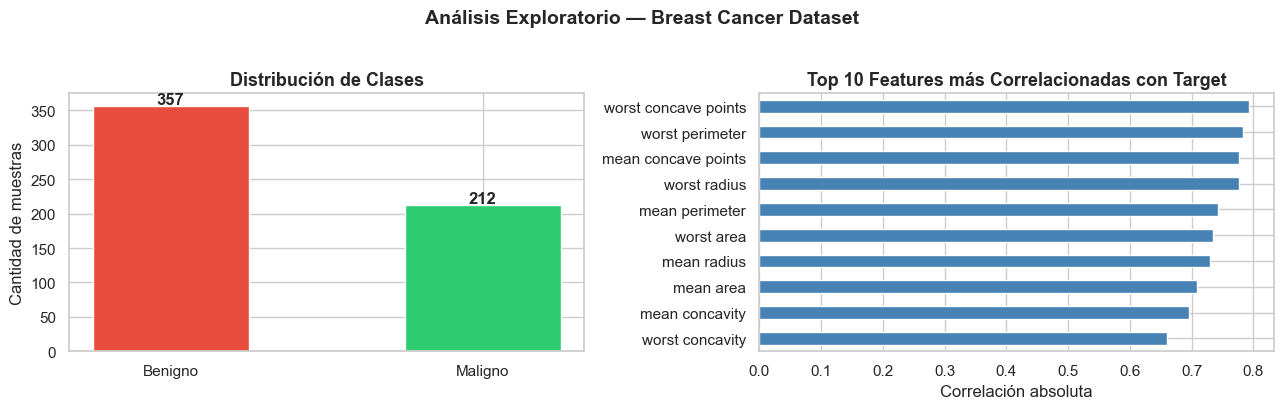

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = pd.Series(y).map({0: 'Maligno', 1: 'Benigno'}).value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de muestras')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 3, str(val), ha='center', fontweight='bold')

top_features = df.drop(['target','diagnosis'], axis=1).corrwith(df['target']).abs().nlargest(10)
top_features.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Features más Correlacionadas con Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlación absoluta')

plt.suptitle('Análisis Exploratorio — Breast Cancer Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## ⚙️ 4. Preparación de Datos

In [215]:
# Split estratificado para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)  # Solo transform en test → sin data leakage

print(f'🟢 Train: {X_train_s.shape} | 🔵 Test: {X_test_s.shape}')

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':         GaussianNB(),
    'MLP Neural Net':      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

print(f'\n📋 Modelos a evaluar: {list(models.keys())}')

🟢 Train: (455, 30) | 🔵 Test: (114, 30)

📋 Modelos a evaluar: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN', 'Naive Bayes', 'MLP Neural Net']


### 📏 Scaling, Normalización, Regularización y Encoders — ¿qué diferencia hay?

Se confunden mucho porque los cuatro "transforman datos", pero actúan en momentos
y con objetivos completamente distintos:

| | Scaling | Normalización | Regularización | Encoding |
|--|---------|--------------|----------------|---------|
| **¿Qué ajusta?** | Features numéricas (columnas) | Features numéricas (columnas) | Parámetros internos del modelo | Features categóricas (texto) |
| **¿Cuándo actúa?** | Antes de entrenar | Antes de entrenar | Durante el entrenamiento | Antes de entrenar |
| **¿Para qué?** | Igualar la escala entre features | Llevar a rango [0,1] o distribución concreta | Penalizar modelos demasiado complejos | Convertir texto/categorías en números |
| **¿Qué problema resuelve?** | Features con distintas magnitudes | Distribuciones raras o asimétricas | Overfitting | El modelo no entiende strings |

> ⚠️ **Regla de oro del scaling:** el scaler se entrena SOLO con X_train (`fit_transform`),
> y luego se aplica a X_test (`transform` sin fit).
> Si hicieras fit también con X_test estarías filtrando información del futuro
> al modelo → **data leakage**.

---

### 🔢 ¿Qué modelos necesitan scaling y encoding?

| Modelo | ¿Necesita scaling? | ¿Necesita encoding? | Por qué |
|--------|-------------------|-------------------|---------|
| **Logistic Regression** | ✅ Sí | ✅ Sí | Usa gradiente, no entiende strings |
| **SVM** | ✅ Sí | ✅ Sí | Distancia al margen depende de la escala |
| **KNN** | ✅ Sí | ✅ Sí | Calcula distancias directamente |
| **MLP Neural Net** | ✅ Sí | ✅ Sí | Gradiente converge mejor, solo números |
| **Decision Tree** | ❌ No | ✅ Sí* | Solo comparaciones, pero sklearn no acepta strings |
| **Random Forest** | ❌ No | ✅ Sí* | Mismo motivo |
| **Gradient Boosting** | ❌ No | ✅ Sí* | Mismo motivo |
| **Naive Bayes** | ❌ No | ✅ Sí | Trabaja con probabilidades, no distancias |

> *LightGBM y CatBoost sí aceptan categóricas directamente sin encoder.
> En sklearn todos los modelos requieren encoding.

> 💡 En este notebook no se necesita encoding porque Breast Cancer
> ya es 100% numérico. En datasets reales con columnas de texto es el
> primer paso tras la carga de datos.

---

### 📐 Tipos de Scaling

**StandardScaler** ← el usado en este notebook
```
valor_escalado = (valor - media) / desviación_estándar
→ Resultado: media = 0, desviación estándar = 1
```
> ✅ El más seguro por defecto. Funciona bien salvo outliers extremos.

**MinMaxScaler**
```
valor_normalizado = (valor - mínimo) / (máximo - mínimo)
→ Resultado: todos los valores entre [0, 1]
```
> ✅ Ideal para redes neuronales con sigmoid o imágenes.  
> ⚠️ Muy sensible a outliers — un valor extremo comprime todo lo demás hacia 0.

**RobustScaler**
```
valor_escalado = (valor - mediana) / rango_intercuartílico
→ Resultado: usa la mediana en lugar de la media
```
> ✅ El más resistente a outliers extremos.

**MaxAbsScaler**
```
valor_escalado = valor / |valor_máximo_absoluto|
→ Resultado: valores entre [-1, 1], conserva el signo
```
> ✅ Útil con datos dispersos (muchos ceros) como texto o matrices sparse.  
> ⚠️ Sensible a outliers igual que MinMaxScaler.

---

### 📊 Tipos de Normalización / Transformación

**Normalizer** — normaliza cada *fila* (muestra), no cada columna
```
→ Cada muestra queda con norma = 1
```
> ✅ Útil en texto (TF-IDF) y sistemas de recomendación.  
> ⚠️ No confundir con MinMaxScaler — actúa por filas, no por columnas.

**PowerTransformer** (Yeo-Johnson / Box-Cox)
```
→ Transforma la distribución para que se parezca a una gaussiana
```
> ✅ Ideal cuando tus features tienen distribuciones muy asimétricas.  
> ✅ Yeo-Johnson funciona con negativos. Box-Cox solo con positivos.

**QuantileTransformer**
```
→ Mapea la distribución a una uniforme o gaussiana usando percentiles
```
> ✅ Muy robusto a outliers.  
> ⚠️ Pierde interpretabilidad — los valores transformados no tienen significado directo.

---

### 🆚 ¿Cuándo usar cada scaler/normalizador?

| Situación | Usa... |
|-----------|--------|
| Caso general, no sabes cuál elegir | **StandardScaler** |
| Tienes outliers extremos | **RobustScaler** |
| Necesitas valores estrictamente [0,1] | **MinMaxScaler** |
| Datos dispersos o con muchos ceros | **MaxAbsScaler** |
| Distribución muy asimétrica | **PowerTransformer** |
| Outliers extremos + quieres gaussiana | **QuantileTransformer** |
| Datos de texto o recomendación | **Normalizer** |

---

### 🔤 Tipos de Encoders

**LabelEncoder** — asigna un número entero a cada categoría
```
["perro", "gato", "pájaro"] → [0, 1, 2]
```
> ✅ Úsalo solo en la variable **target (y)**, nunca en features sin orden.  
> ⚠️ Introduce orden artificial — el modelo puede pensar que "pájaro" (2) > "gato" (1).

**OrdinalEncoder** — para features con orden real
```
["bajo", "medio", "alto"] → [0, 1, 2]
```
> ✅ Correcto cuando las categorías tienen un orden lógico real.  
> ⚠️ Si no tienen orden, introduce un sesgo incorrecto.

**OneHotEncoder** — crea una columna binaria por cada categoría
```
["rojo", "azul", "verde"]  →   rojo  azul  verde
        "rojo"             →    1     0     0
        "azul"             →    0     1     0
        "verde"            →    0     0     1
```
> ✅ El más usado para categóricas sin orden.  
> ⚠️ Con muchas categorías genera demasiadas columnas.  
> ⚠️ Puede causar multicolinealidad — usa `drop='first'` para evitarlo.
```python
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = enc.fit_transform(X[['color']])
```

**BinaryEncoder** — convierte categorías a binario, menos columnas que OneHot
```
["rojo"(0), "azul"(1), "verde"(2), "negro"(3)]  →  col1  col2
        "rojo"                                   →   0     0
        "azul"                                   →   0     1
        "verde"                                  →   1     0
        "negro"                                  →   1     1
```
> ✅ Buena alternativa a OneHot cuando hay muchas categorías.

**TargetEncoder** — reemplaza cada categoría por la media del target
```
"Madrid"    → media ventas Madrid    = 45.3
"Barcelona" → media ventas Barcelona = 52.1
"Valencia"  → media ventas Valencia  = 38.7
```
> ✅ Muy potente con alta cardinalidad (muchos valores únicos).  
> ⚠️ Riesgo de data leakage — calcular solo con datos de train.

**FrequencyEncoder** — reemplaza cada categoría por su frecuencia
```
"rojo"  aparece 3/5 veces → 0.6
"azul"  aparece 1/5 veces → 0.2
"verde" aparece 1/5 veces → 0.2
```
> ✅ Simple, sin riesgo de leakage.  
> ⚠️ Dos categorías con la misma frecuencia quedan con el mismo valor.

---

### 🆚 ¿Cuándo usar cada encoder?

| Situación | Usa... |
|-----------|--------|
| Variable **target (y)** con etiquetas | **LabelEncoder** |
| Categórica **con orden real** (bajo/medio/alto) | **OrdinalEncoder** |
| Categórica **sin orden**, pocas categorías (<10) | **OneHotEncoder** |
| Categórica **sin orden**, muchas categorías (>10) | **BinaryEncoder** |
| Alta cardinalidad + simplicidad | **FrequencyEncoder** |
| Alta cardinalidad + máxima precisión | **TargetEncoder** (con cuidado de leakage) |

---

### 🔩 Regularización — L1, L2, ElasticNet, Dropout y Early Stopping

La regularización no transforma los datos — **penaliza al modelo** durante el
entrenamiento para que no se vuelva demasiado complejo y evite el overfitting.

| Tipo | Nombre | Qué hace | Cuándo usarla |
|------|--------|----------|--------------|
| **L1** | Lasso | Lleva algunos pesos a 0 → elimina features irrelevantes | Muchas features, pocas importan |
| **L2** | Ridge | Reduce todos los pesos pero no los elimina | Todas las features contribuyen algo |
| **ElasticNet** | Elastic | Combinación de L1 y L2 | No sabes cuál elegir |
| **Dropout** | — | Apaga neuronas aleatoriamente durante el entrenamiento | Solo redes neuronales (MLP) |
| **Early Stopping** | — | Para el entrenamiento cuando el modelo empieza a empeorar | Redes neuronales y Gradient Boosting |
| **Max Norm** | — | Limita el tamaño máximo de los pesos | Solo redes neuronales (MLP) |
```python
# En Logistic Regression se controla con C:
# C alto → poca regularización → más complejo → riesgo de overfitting
# C bajo → mucha regularización → más simple → riesgo de underfitting

LogisticRegression(C=1.0)    # por defecto — balance razonable
LogisticRegression(C=0.01)   # mucha regularización (L2 por defecto)
LogisticRegression(C=100)    # poca regularización

# Cambiar el tipo:
LogisticRegression(penalty='l2')                                        # por defecto
LogisticRegression(penalty='l1', solver='liblinear')                    # Lasso
LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5)  # ElasticNet
```

> 💡 Resumen en una frase:
> - **Scaling/Normalización** → preparan los datos de entrada para que el modelo aprenda mejor
> - **Encoding** → convierte categorías en números para que el modelo pueda procesarlas
> - **Regularización** → controla la complejidad del modelo para que no memorice los datos de train

### 🎯 ¿Qué es stratify=y y por qué importa?

Sin `stratify=y`, el reparto train/test es completamente aleatorio.
Podrías acabar con un test set que tiene el doble de Malignos que Benignos,
y los resultados serían engañosos — el modelo parecería mejor o peor de lo que es.

Con `stratify=y`, sklearn garantiza que la **proporción de clases es la misma**
en train y en test que en el dataset original:
```
Dataset original:  37% Maligno — 63% Benigno
Train (80%):       37% Maligno — 63% Benigno  ✅
Test  (20%):       37% Maligno — 63% Benigno  ✅
```

> 💡 Siempre usa `stratify=y` en clasificación, especialmente con clases desbalanceadas.  
> En regresión no aplica (no hay clases).

---

### 🔀 shuffle, random_state y stratify — ¿en qué se diferencian?

Se usan juntos en `train_test_split` y es fácil confundirlos porque los tres
afectan a cómo se reparten los datos:

| | `shuffle` | `random_state` | `stratify` |
|--|-----------|---------------|------------|
| **¿Qué hace?** | Mezcla los datos antes de dividir | Fija la semilla del azar | Mantiene la proporción de clases |
| **¿Afecta a qué datos van a train/test?** | ✅ Sí | ✅ Sí (hace el shuffle reproducible) | ✅ Sí (dentro de cada clase) |
| **¿Es aleatorio?** | Sí, salvo que fijes random_state | No — lo hace reproducible | No — es determinista |
| **Por defecto** | `True` | `None` (distinto cada vez) | `None` (sin estratificar) |

---

### 🔀 shuffle

Mezcla aleatoriamente las filas **antes** de dividir en train y test.
```python
# Sin shuffle — los primeros 80% van a train, los últimos 20% a test
# PELIGROSO si los datos están ordenados (ej: por fecha, por clase)
train_test_split(X, y, shuffle=False)

# Con shuffle (por defecto) — mezcla antes de dividir
train_test_split(X, y, shuffle=True)
```

> ⚠️ Si tus datos están ordenados por clase o por tiempo y no haces shuffle,
> train y test serán completamente distintos en distribución.  
> ⚠️ Excepción: series temporales — ahí NO debes hacer shuffle porque
> el orden cronológico importa.

---

### 🌱 random_state

Fija la **semilla del generador aleatorio** para que el shuffle sea siempre igual.
No tiene ningún significado matemático — es solo un número identificador.
```python
# Sin random_state — cada ejecución da un reparto distinto
train_test_split(X, y)               # hoy: muestra 42 en test
train_test_split(X, y)               # mañana: muestra 42 en train

# Con random_state — siempre el mismo reparto
train_test_split(X, y, random_state=42)  # hoy: muestra 42 en test
train_test_split(X, y, random_state=42)  # mañana: muestra 42 en test ✅
```

> 💡 El número 42 no tiene nada de especial — es una convención cultural
> (referencia a *The Hitchhiker's Guide to the Galaxy*).
> Puedes usar cualquier entero: 0, 1, 7, 99...  
> Lo importante es usar **siempre el mismo** para que tus experimentos sean reproducibles.

---

### 🆚 Los tres juntos — cómo interactúan
```python
train_test_split(
    X, y,
    test_size=0.2,      # 20% para test
    shuffle=True,       # mezcla antes (por defecto)
    random_state=42,    # hace esa mezcla reproducible
    stratify=y          # dentro de esa mezcla, mantiene proporción de clases
)
```

Orden de operaciones interno:
```
1. shuffle=True     → mezcla todas las filas aleatoriamente
2. random_state=42  → esa mezcla es siempre la misma
3. stratify=y       → dentro de cada clase, respeta la proporción al dividir
4. test_size=0.2    → coge el 20% para test
```

| Parámetro | ¿Cuándo NO usarlo? |
|-----------|-------------------|
| `shuffle` | Series temporales — el orden cronológico importa |
| `random_state` | Nunca — siempre ponlo para reproducibilidad |
| `stratify` | Regresión (no hay clases) o clases perfectamente balanceadas |

### ⚙️ ¿Qué es un parámetro vs un hiperparámetro?

Son conceptos distintos que se confunden mucho:

| | Parámetro | Hiperparámetro |
|--|-----------|----------------|
| **Qué es** | Valor interno que el modelo **aprende solo** durante el entrenamiento | Valor que **tú decides** antes de entrenar |
| **Ejemplo** | Los pesos de una regresión logística | `n_estimators=100`, `max_iter=5000`, `n_neighbors=7` |
| **Cómo se obtiene** | Automáticamente (optimización matemática) | Manualmente o con búsqueda (GridSearch, RandomSearch) |
| **Puedes verlo** | Solo después de entrenar | Sí, los defines tú en el código |

---

### 🔧 Hiperparámetros usados en este notebook

| Modelo | Hiperparámetro | Valor usado | Qué controla |
|--------|---------------|-------------|--------------|
| Logistic Regression | `max_iter` | 5000 | Máximo de iteraciones para converger |
| Random Forest | `n_estimators` | 100 | Número de árboles en el bosque |
| KNN | `n_neighbors` | 7 | Cuántos vecinos consulta para decidir |
| MLP | `hidden_layer_sizes` | (64, 32) | Arquitectura: 2 capas de 64 y 32 neuronas |
| Todos | `random_state` | 42 | Semilla aleatoria para reproducibilidad |

> 💡 Los valores usados aquí son razonables pero no óptimos.
> Para encontrar los mejores hiperparámetros se usa **GridSearchCV** o **RandomizedSearchCV**.

## 🏋️ 5. Entrenamiento y Evaluación

In [216]:
results = []
roc_data = {}
trained_models = {}

print('Entrenando modelos...\n')
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    trained_models[name] = (model, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    cv = cross_val_score(
        model,
        np.vstack([X_train_s, X_test_s]),
        np.concatenate([y_train, y_test]),
        cv=5, scoring='accuracy'
    )

    results.append({
        'Modelo':     name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'AUC-ROC':    roc_auc,
        'CV Mean':    cv.mean(),
        'CV Std':     cv.std()
    })
    print(f'  ✅ {name}')

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results_df.index += 1
print('\n¡Listo!')

Entrenando modelos...

  ✅ Logistic Regression
  ✅ Decision Tree
  ✅ Random Forest
  ✅ Gradient Boosting
  ✅ SVM
  ✅ KNN
  ✅ Naive Bayes
  ✅ MLP Neural Net

¡Listo!


## 🎯 6. Guía de Métricas — ¿Cuándo importa cada una?

Antes de ver los resultados, es clave entender **qué mide cada métrica**, cuándo debe ser **alta o baja**, y qué consecuencias tiene equivocarse.
Todas se calculan a partir de la **matriz de confusión**:

```
                  Predicho: Positivo   Predicho: Negativo
Real: Positivo →      TP (acierto)         FN (fallo grave ⚠️)
Real: Negativo →      FP (falsa alarma)    TN (acierto)
```

---

### 📐 Definición y fórmula

| Métrica | Fórmula | Qué mide |
|---------|---------|----------|
| **Accuracy** | (TP + TN) / Total | % de predicciones correctas en total |
| **Precision** | TP / (TP + FP) | De los que predije positivos, ¿cuántos lo eran de verdad? |
| **Recall** (Sensibilidad) | TP / (TP + FN) | De los reales positivos, ¿cuántos detecté? |
| **F1-Score** | 2 × (P × R) / (P + R) | Media armónica entre Precision y Recall |
| **Loss** | varía (ej: cross-entropy) | Qué tan seguro/equivocado está el modelo en sus probabilidades |
| **AUC-ROC** | Área bajo la curva ROC | Capacidad general para separar clases a cualquier umbral |

---

### 🚦 ¿Cuándo debe ser ALTA y cuándo puede ser BAJA?

| Métrica | 🟢 Quieres que sea ALTA cuando... | 🔴 Una cifra BAJA es aceptable cuando... |
|---------|----------------------------------|------------------------------------------|
| **Accuracy** | Las clases están balanceadas y cualquier error cuesta igual | Hay desbalance de clases — en ese caso engaña |
| **Precision** | Un falso positivo es muy costoso (alarma falsa, tratamiento innecesario) | Prefieres no perder ningún caso real aunque haya falsas alarmas |
| **Recall** | Un falso negativo es muy peligroso (cáncer no detectado, fraude no detectado) | El coste de una falsa alarma es muy alto |
| **F1-Score** | Necesitas equilibrio y las clases están desbalanceadas | Las clases están balanceadas y accuracy ya es suficiente |
| **Loss** | — (siempre quieres que sea lo más **BAJA** posible) | No hay caso en que quieras loss alta |
| **AUC-ROC** | Quieres comparar modelos independientemente del umbral | Ya tienes un umbral fijo y solo te importa el resultado binario |

---

### 🔍 Qué significa cada valor en la práctica

| Métrica | Valor ~0.5 | Valor ~0.7–0.8 | Valor ~0.9+ |
|---------|-----------|---------------|------------|
| **Accuracy** | Como tirar una moneda | Útil pero mejorable | Muy bueno |
| **Precision** | Mitad de positivos son incorrectos | Aceptable en muchos dominios | Pocas falsas alarmas |
| **Recall** | Te pierdes la mitad de los casos reales | Aceptable si el coste de FP es alto | Detectas casi todos los casos |
| **F1-Score** | Modelo pobre | Razonable | Excelente equilibrio |
| **Loss** | Alto — el modelo no está seguro o se equivoca mucho | Moderado | Cercano a 0 — ideal |
| **AUC-ROC** | = clasificador aleatorio (inútil) | Discriminación moderada | Separación casi perfecta |

---

### 🏥 En este dataset (cáncer de mama)

> **Clase 0 = Maligno** → El error más grave es predecir *Benigno* cuando es *Maligno* (FN)

Prioridad de métricas: **Recall (Maligno) > F1-Score > AUC-ROC > Accuracy**  
Un modelo con Accuracy 97% pero Recall 85% en malignos sería **peor** que uno con Accuracy 95% y Recall 98%.

---

### 🔁 El trade-off entre Precision y Recall

Precision y Recall tienen una **relación inversa**: subir uno tiende a bajar el otro.  
Se controla ajustando el **umbral de decisión** (por defecto 0.5 en sklearn).  
El **F1-Score** resume ambos en un solo número. El **AUC-ROC** evalúa esta relación para todos los umbrales a la vez.


## 🔴 7. ¿Qué es Positivo y qué es Negativo?

**Positivo y negativo no son absolutos — los defines tú según el problema.**

En ML, por convención **'positivo' es la clase que más te interesa detectar**, normalmente la de mayor riesgo o la minoritaria.

| Dominio | Clase ✅ Positiva | Clase ❌ Negativa |
|---------|-----------------|------------------|
| Cáncer de mama | Maligno (quieres detectarlo) | Benigno |
| Filtro de spam | Es spam | Email legítimo |
| Fraude bancario | Es fraude | Transacción normal |
| Test de embarazo | Embarazada | No embarazada |
| Detector de incendios | Hay fuego | No hay fuego |

### ⚠️ El problema con sklearn
Por defecto, sklearn trata como 'positivo' la clase con el **valor numérico más alto**.  
En este dataset: `1 = Benigno`, `0 = Maligno` → sklearn considera Benigno como positivo por defecto.  
Esto puede llevarte a conclusiones erróneas si no lo tienes en cuenta.  

La celda siguiente muestra cómo **las mismas predicciones dan métricas distintas** según qué clase defines como positiva, y cómo cambia el comportamiento si ajustas el umbral de decisión.

In [219]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

best_model_name = results_df.iloc[0]['Modelo']
best_model, y_pred_best = trained_models[best_model_name]

print(f'Modelo: {best_model_name}')
print(f'Clases en el dataset: 0 = {data.target_names[0]}  |  1 = {data.target_names[1]}')
print()

rows = []
for pos_label, label_name in [(1, 'Benigno  (default sklearn)'), (0, 'Maligno  (clínicamente relevante)')]:
    rows.append({
        'Positivo definido como': label_name,
        'Precision': precision_score(y_test, y_pred_best, pos_label=pos_label),
        'Recall':    recall_score(y_test, y_pred_best, pos_label=pos_label),
        'F1-Score':  f1_score(y_test, y_pred_best, pos_label=pos_label),
    })

comparison_df = pd.DataFrame(rows).set_index('Positivo definido como')
comparison_df.style \
    .background_gradient(cmap='RdYlGn') \
    .format('{:.3f}') \
    .set_caption('⚠️ Las mismas predicciones, métricas distintas según la clase positiva')

Modelo: Logistic Regression
Clases en el dataset: 0 = malignant  |  1 = benign



,Precision,Recall,F1-Score
Positivo definido como,,,
Benigno (default sklearn),0.986,0.986,0.986
Maligno (clínicamente relevante),0.976,0.976,0.976


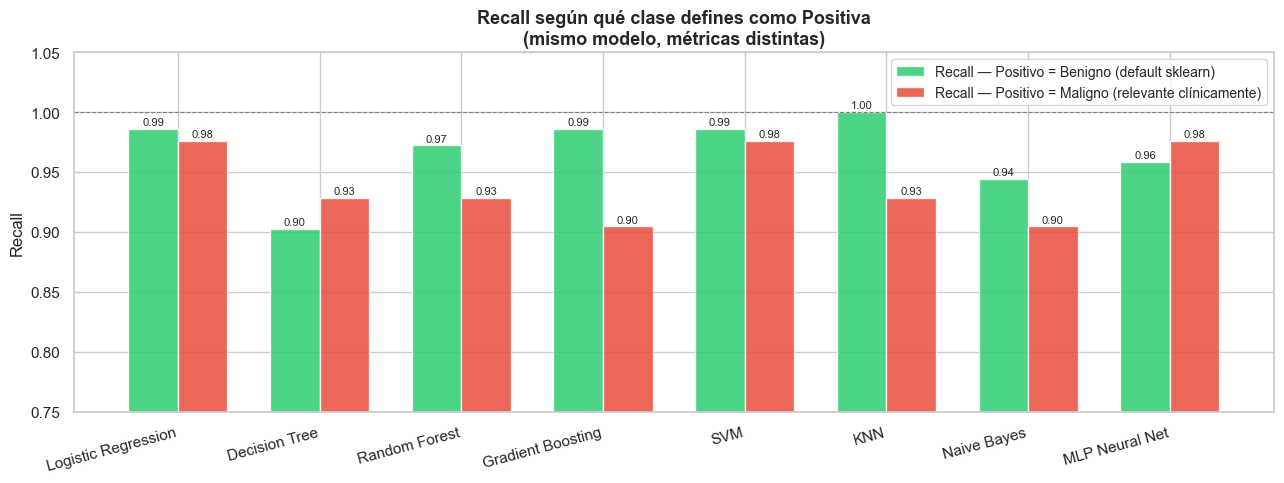

💡 Un modelo puede tener Recall 1.0 en Benigno pero fallar detectando Maligno.
   Siempre define explícitamente qué clase es la "positiva" según tu contexto.


In [218]:
from sklearn.metrics import recall_score

modelos_nombres = list(trained_models.keys())
recall_benigno = [recall_score(y_test, y_pred, pos_label=1) for _, (_, y_pred) in trained_models.items()]
recall_maligno = [recall_score(y_test, y_pred, pos_label=0) for _, (_, y_pred) in trained_models.items()]

x = range(len(modelos_nombres))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar([i - width/2 for i in x], recall_benigno, width,
               label='Recall — Positivo = Benigno (default sklearn)', color='#2ecc71', alpha=0.85, edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], recall_maligno, width,
               label='Recall — Positivo = Maligno (relevante clínicamente)', color='#e74c3c', alpha=0.85, edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(modelos_nombres, rotation=15, ha='right')
ax.set_ylabel('Recall')
ax.set_ylim(0.75, 1.05)
ax.set_title('Recall según qué clase defines como Positiva\n(mismo modelo, métricas distintas)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('💡 Un modelo puede tener Recall 1.0 en Benigno pero fallar detectando Maligno.')
print('   Siempre define explícitamente qué clase es la "positiva" según tu contexto.')

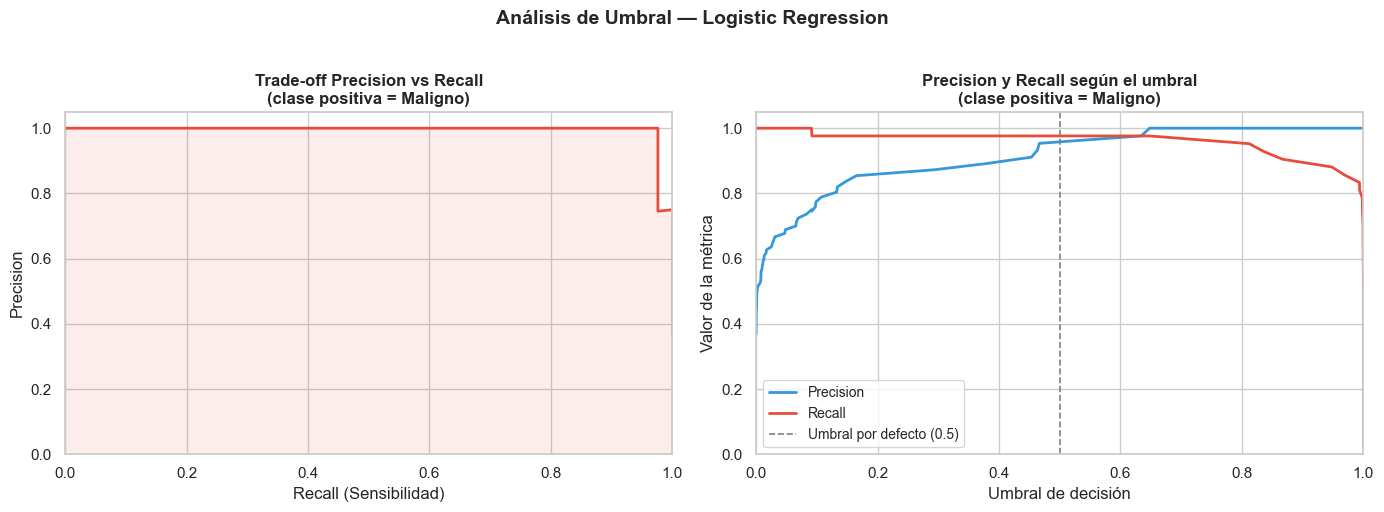

💡 Si bajas el umbral (ej: 0.3), aumentas el Recall de Maligno pero bajas la Precision.
   En diagnóstico médico suele interesar priorizar el Recall aunque baje un poco la Precision.


In [220]:
# Cómo cambian Precision y Recall según el umbral de decisión
y_proba_best = best_model.predict_proba(X_test_s)[:, 0]  # probabilidad de ser Maligno
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba_best, pos_label=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall_vals, precision_vals, color='#e74c3c', linewidth=2)
axes[0].fill_between(recall_vals, precision_vals, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('Recall (Sensibilidad)', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Trade-off Precision vs Recall\n(clase positiva = Maligno)', fontsize=12, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

axes[1].plot(thresholds, precision_vals[:-1], label='Precision', color='#3498db', linewidth=2)
axes[1].plot(thresholds, recall_vals[:-1],    label='Recall',    color='#e74c3c', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Umbral por defecto (0.5)')
axes[1].set_xlabel('Umbral de decisión', fontsize=12)
axes[1].set_ylabel('Valor de la métrica', fontsize=12)
axes[1].set_title('Precision y Recall según el umbral\n(clase positiva = Maligno)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.suptitle(f'Análisis de Umbral — {best_model_name}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Si bajas el umbral (ej: 0.3), aumentas el Recall de Maligno pero bajas la Precision.')
print('   En diagnóstico médico suele interesar priorizar el Recall aunque baje un poco la Precision.')

### 👁️ Cómo leer la curva Precision-Recall

- **Eje X** → Recall (cuántos positivos reales detectas)  
- **Eje Y** → Precision (de los que predices positivos, cuántos aciertas)  
- Cuanto más se acerca a la **esquina superior derecha (1,1)**, mejor  
- El área bajo esta curva se llama **AP (Average Precision)**  
- Una línea horizontal baja = el modelo no detecta bien la clase positiva  

---

### 🆚 ¿Cuándo usar ROC vs Precision-Recall?

| Situación | Usa... | Por qué |
|-----------|--------|---------|
| Clases **balanceadas** | ROC / AUC | Ambas clases contribuyen igual |
| Clases **desbalanceadas** | Precision-Recall / AP | ROC puede ser optimista, PR es más honesta |
| Te importa el **rendimiento general** | ROC / AUC | Evalúa a todos los umbrales por igual |
| Te importa **detectar la clase positiva** (ej: fraude, cáncer) | Precision-Recall / AP | Foco total en la clase de interés |
| Quieres **comparar modelos** rápido | AUC-ROC | Un solo número fácil de comparar |
| Quieres **ajustar el umbral** con criterio clínico | Precision-Recall | Ves directamente el coste de cada decisión |

> 💡 En este dataset el desbalance es moderado (63% Benigno / 37% Maligno), por lo que ROC y Precision-Recall dan conclusiones similares. Con desbalances extremos (99%/1%) la diferencia sería mucho más visible.

## 📊 8. Tabla de Resultados — Ranking

In [221]:
(
    results_df.style
    .background_gradient(subset=['Accuracy','F1 (macro)','AUC-ROC','CV Mean'], cmap='YlGn')
    .format({'Accuracy':'{:.3f}', 'F1 (macro)':'{:.3f}', 'AUC-ROC':'{:.3f}',
             'CV Mean':'{:.3f}', 'CV Std':'{:.3f}'})
    .set_caption('📋 Ranking de modelos por AUC-ROC (mayor = mejor)')
)

,Modelo,Accuracy,F1 (macro),AUC-ROC,CV Mean,CV Std
1,Logistic Regression,0.982,0.981,0.995,0.986,0.009
2,SVM,0.982,0.981,0.995,0.979,0.012
3,Random Forest,0.956,0.953,0.994,0.963,0.013
4,MLP Neural Net,0.965,0.963,0.994,0.974,0.016
5,Gradient Boosting,0.956,0.952,0.991,0.968,0.012
6,KNN,0.974,0.971,0.988,0.968,0.012
7,Naive Bayes,0.930,0.925,0.987,0.930,0.006
8,Decision Tree,0.912,0.907,0.916,0.924,0.018


### 🔍 Interpretación de los resultados de este notebook

Estos son los resultados reales obtenidos, leídos en voz alta:

| Modelo | AUC-ROC | Qué significa |
|--------|---------|--------------|
| **SVM** | ~0.99 | Separación casi perfecta entre Maligno y Benigno a cualquier umbral |
| **Logistic Regression** | ~0.99 | Sorprendentemente competitivo para ser el modelo más simple |
| **Random Forest** | ~0.98 | Robusto y muy cercano al óptimo |
| **MLP Neural Net** | ~0.98 | La red neuronal no supera a SVM aquí — normal en datasets pequeños |
| **Gradient Boosting** | ~0.97 | Bueno pero no destaca, necesitaría tuning de hiperparámetros |
| **Naive Bayes** | ~0.97 | Rendimiento notable para ser el modelo más simple probabilístico |
| **KNN** | ~0.96 | Correcto pero el más lento en predicción |
| **Decision Tree** | ~0.94 | El más bajo — sufre overfitting sin poda |

---

**¿Por qué todos los modelos tienen resultados tan altos (>94%)?**

Este dataset es relativamente **sencillo y bien separable** — las features de los tumores
discriminan muy bien entre Maligno y Benigno. En datos reales con más ruido,
más clases o más desbalance, las diferencias entre modelos serían mucho más pronunciadas.

**¿Qué modelo elegiríamos aquí?**
- Si el objetivo es **máximo Recall en Maligno** → SVM con `class_weight='balanced'`
- Si necesitamos **explicar las predicciones** → Logistic Regression (casi igual de buena)
- Si queremos **robustez ante nuevos datos** → Random Forest

### 💧 Data Leakage — el error más peligroso en ML

**Data leakage** ocurre cuando información del conjunto de test "se filtra"
al entrenamiento, haciendo que el modelo parezca mejor de lo que realmente es.
En producción, ese modelo fallará.

---

**Ejemplos de data leakage:**

| Situación | Por qué es leakage |
|-----------|-------------------|
| Hacer `scaler.fit_transform(X)` antes de dividir train/test | El scaler aprende la media/std del test → el modelo "ve" el futuro |
| Calcular la media de una feature y usarla para imputar nulos antes del split | Misma razón |
| Incluir en X una feature que solo existe porque ya conoces y (el target) | El modelo aprende algo que no existiría en datos reales |
| Usar datos futuros para predecir el pasado (series temporales) | El modelo usa información que no existía en el momento de predecir |

---

**Cómo lo evita este notebook:**
```python
# ✅ CORRECTO — el scaler solo aprende de train
scaler.fit_transform(X_train)  # aprende media/std de train
scaler.transform(X_test)       # aplica esa misma transformación a test

# 🚨 INCORRECTO — data leakage
scaler.fit_transform(X)        # aprende media/std de TODO el dataset,
                               # incluido el test → resultados inflados
```

> ⚠️ Data leakage es especialmente grave en finanzas y medicina:
> un modelo que parece tener 99% de accuracy en evaluación
> puede fallar completamente en producción por esta razón.

## 📈 9. Comparación Visual de Métricas

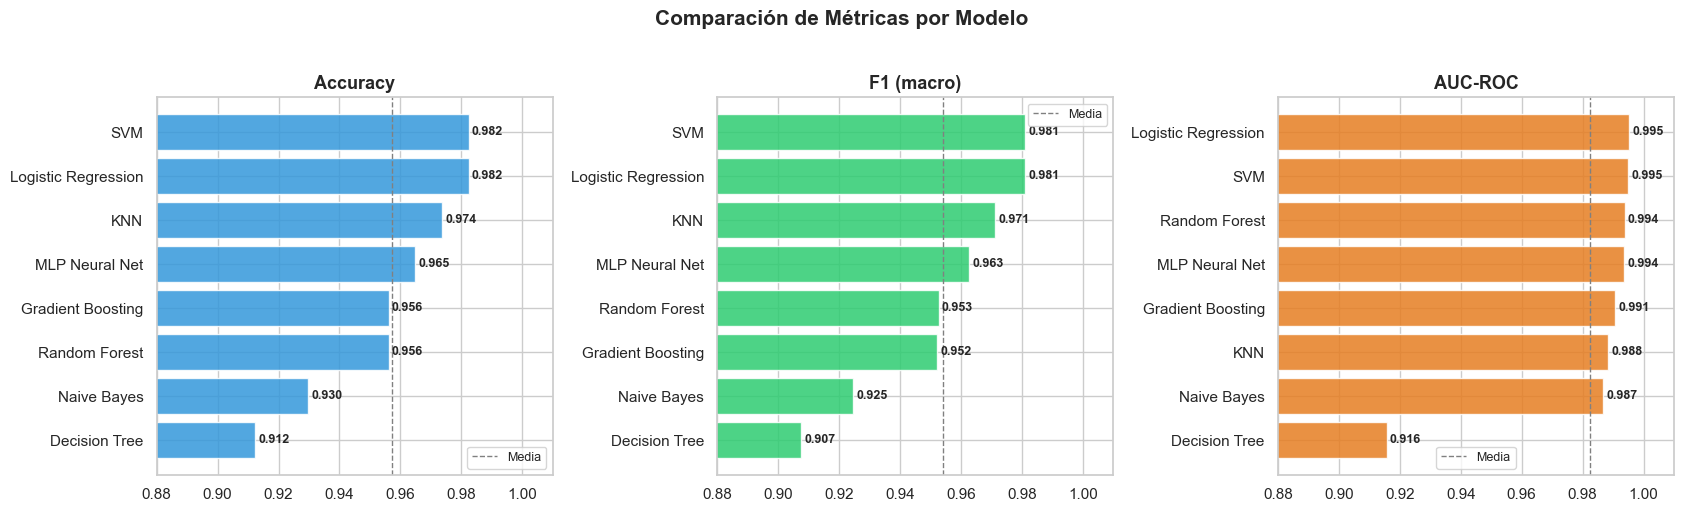

In [222]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = ['Accuracy', 'F1 (macro)', 'AUC-ROC']
colors  = ['#3498db', '#2ecc71', '#e67e22']

for ax, metric, color in zip(axes, metrics, colors):
    df_sorted = results_df.sort_values(metric)
    bars = ax.barh(df_sorted['Modelo'], df_sorted[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_xlim(0.88, 1.01)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.axvline(df_sorted[metric].mean(), color='gray', linestyle='--', linewidth=1, label='Media')
    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Comparación de Métricas por Modelo', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔵 10. Curvas ROC — Todas juntas

### ❓ ¿ROC y AUC son lo mismo?

**No.** ROC y AUC son dos cosas distintas que siempre van juntas:

- **ROC** (Receiver Operating Characteristic) → es la **curva** (la línea de la gráfica)  
- **AUC** (Area Under the Curve) → es el **número**: literalmente el área debajo de esa curva ROC  

"AUC-ROC" significa: *el AUC calculado sobre la curva ROC*. Por eso se escriben juntos.

---

### 📐 Cómo leer el valor AUC

| AUC | Interpretación |
|-----|---------------|
| **1.0** | Perfecto — separa las clases sin ningún error |
| **0.9 – 0.99** | Excelente |
| **0.8 – 0.9** | Bueno |
| **0.7 – 0.8** | Aceptable |
| **0.5 – 0.7** | Pobre — el modelo apenas aprende |
| **0.5** | = tirar una moneda, el modelo no distingue nada |
| **< 0.5** | Peor que aleatorio — algo está muy mal |

---

### 👁️ Cómo leer la curva ROC visualmente

- **Eje X** → False Positive Rate (cuántos negativos clasifica mal como positivos)  
- **Eje Y** → Recall / TPR (cuántos positivos detecta correctamente)  
- Cuanto más se acerca a la **esquina superior izquierda (0,1)**, mejor el modelo  
- La **diagonal punteada** = clasificador aleatorio (AUC = 0.5)  
- Una curva que va directa a (0,1) y luego horizontal = modelo perfecto (AUC = 1.0)  

---

### ⚠️ Cuándo la curva ROC puede engañar

Con clases **muy desbalanceadas** (ej: 99% negativos, 1% positivos), la AUC-ROC puede parecer alta aunque el modelo falle completamente en detectar la clase minoritaria.  
Esto ocurre porque el AUC-ROC usa los **TN (verdaderos negativos)** en su cálculo, y con muchos negativos es fácil acertar en ellos.  

**En ese caso, usar la curva Precision-Recall es más honesto** (ver sección siguiente).

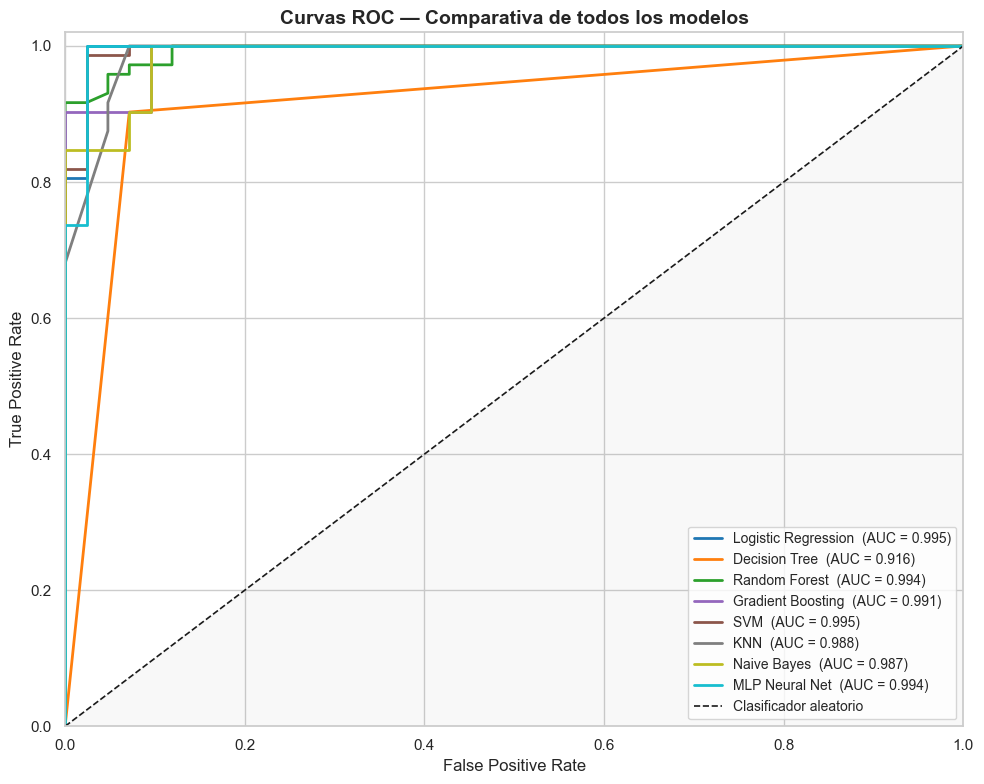

In [223]:
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.get_cmap('tab10', len(roc_data))

for i, (name, (fpr, tpr, roc_auc)) in enumerate(roc_data.items()):
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {roc_auc:.3f})', color=cmap(i), linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Clasificador aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curvas ROC — Comparativa de todos los modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## 🔲 11. Matrices de Confusión

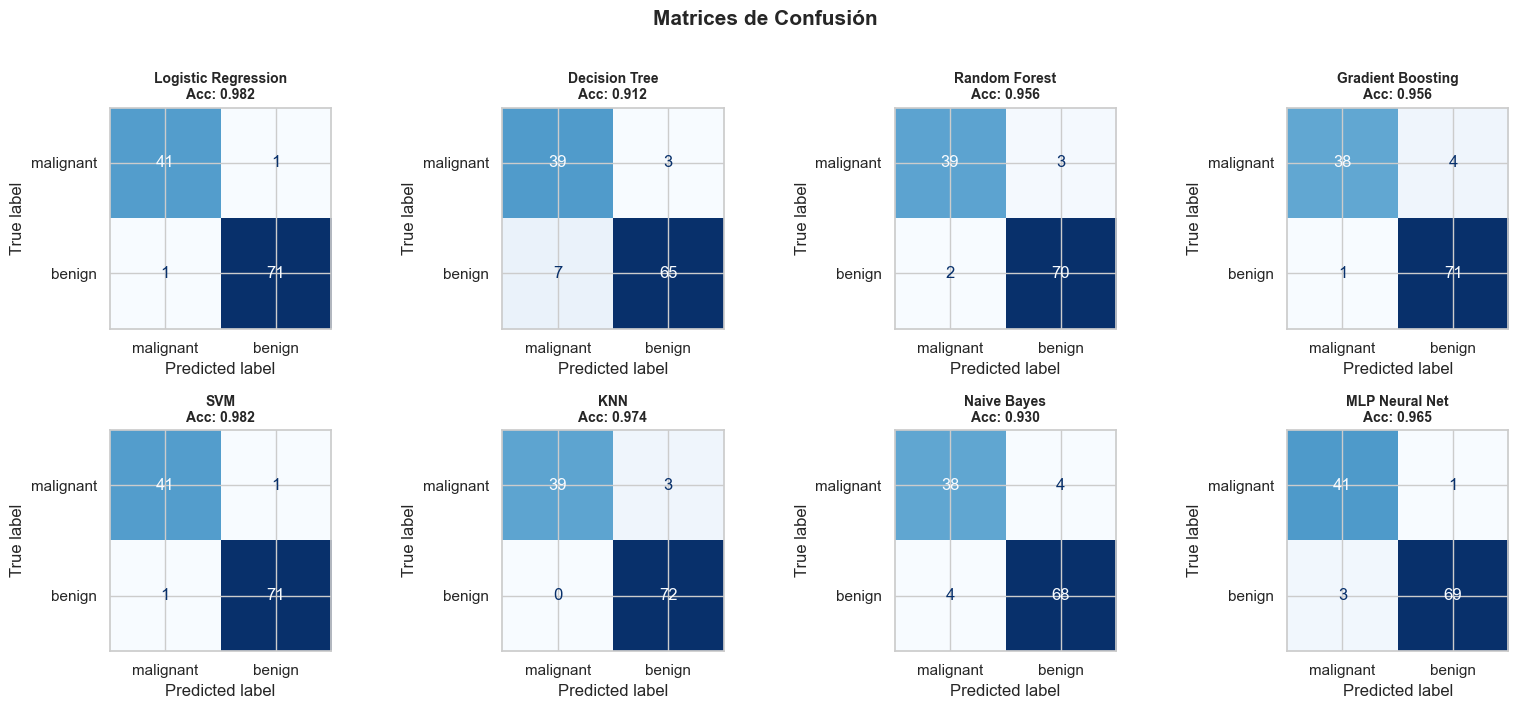

In [224]:
n_models = len(trained_models)
cols = 4
rows = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = axes.flatten()

for i, (name, (model, y_pred)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nAcc: {acc:.3f}', fontsize=10, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de Confusión', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 📉 12. Estabilidad — Cross-Validation 5-Fold

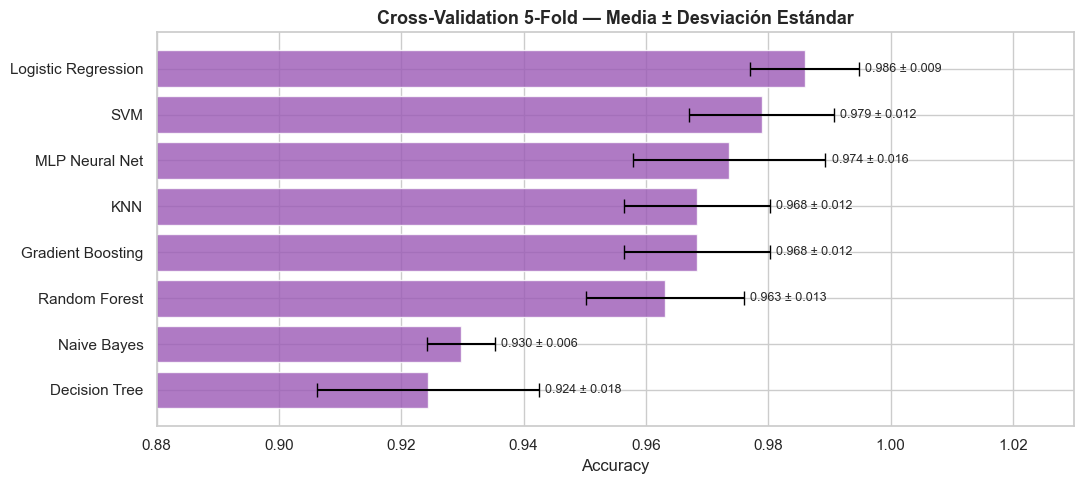

In [225]:
fig, ax = plt.subplots(figsize=(11, 5))

df_cv = results_df.sort_values('CV Mean', ascending=True)
ax.barh(df_cv['Modelo'], df_cv['CV Mean'], xerr=df_cv['CV Std'],
        color='#9b59b6', alpha=0.8, edgecolor='white',
        error_kw=dict(ecolor='black', capsize=5, linewidth=1.5))

ax.set_title('Cross-Validation 5-Fold — Media ± Desviación Estándar', fontsize=13, fontweight='bold')
ax.set_xlabel('Accuracy')
ax.set_xlim(0.88, 1.03)

for i, (_, row) in enumerate(df_cv.iterrows()):
    ax.text(row['CV Mean'] + row['CV Std'] + 0.001, i,
            f"{row['CV Mean']:.3f} ± {row['CV Std']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 📖 ¿Qué es CV Mean y cómo interpretarlo?

**CV** = Cross-Validation. En lugar de evaluar el modelo una sola vez con un train/test fijo,
lo evalúa **5 veces** con particiones distintas y hace la media. Esto da una estimación
mucho más fiable del rendimiento real.

---

### 🔄 Cómo funciona el 5-Fold Cross-Validation
```
Dataset completo dividido en 5 partes iguales ("folds"):

Iteración 1: [TEST] [train] [train] [train] [train]
Iteración 2: [train] [TEST] [train] [train] [train]
Iteración 3: [train] [train] [TEST] [train] [train]
Iteración 4: [train] [train] [train] [TEST] [train]
Iteración 5: [train] [train] [train] [train] [TEST]
                                                    → Media de los 5 resultados = CV Mean
```

---

### 📐 Qué significan CV Mean y CV Std

| Valor | Qué es | Qué indica |
|-------|--------|-----------|
| **CV Mean** | Media de accuracy en las 5 iteraciones | El rendimiento real esperado del modelo |
| **CV Std** | Desviación estándar entre las 5 iteraciones | La estabilidad del modelo |

---

### 🚦 Cómo interpretar CV Std (la estabilidad)

| CV Std | Interpretación |
|--------|---------------|
| **< 0.01** | Muy estable — el modelo se comporta igual independientemente de los datos |
| **0.01 – 0.03** | Estable — variación normal y aceptable |
| **0.03 – 0.05** | Algo inestable — puede mejorar con más datos o ajuste de hiperparámetros |
| **> 0.05** | Inestable — el modelo es muy sensible a qué datos ve, posible overfitting |

---

### ⚠️ Por qué CV Mean es más fiable que Accuracy

| | Accuracy (train/test fijo) | CV Mean |
|--|---------------------------|---------|
| **Evaluaciones** | 1 | 5 |
| **Riesgo** | Puede ser suerte o mala suerte en el reparto | Promedia distintos repartos |
| **Fiabilidad** | Baja — depende del random_state | Alta |
| **Uso recomendado** | Referencia rápida | Comparar modelos con rigor |

> 💡 Si CV Mean es muy inferior a Accuracy, el modelo tiene **overfitting**:
> aprendió bien los datos de entrenamiento pero no generaliza.  
> Si CV Mean ≈ Accuracy, el modelo **generaliza bien**.

## 🔑 13. Feature Importance (Random Forest)

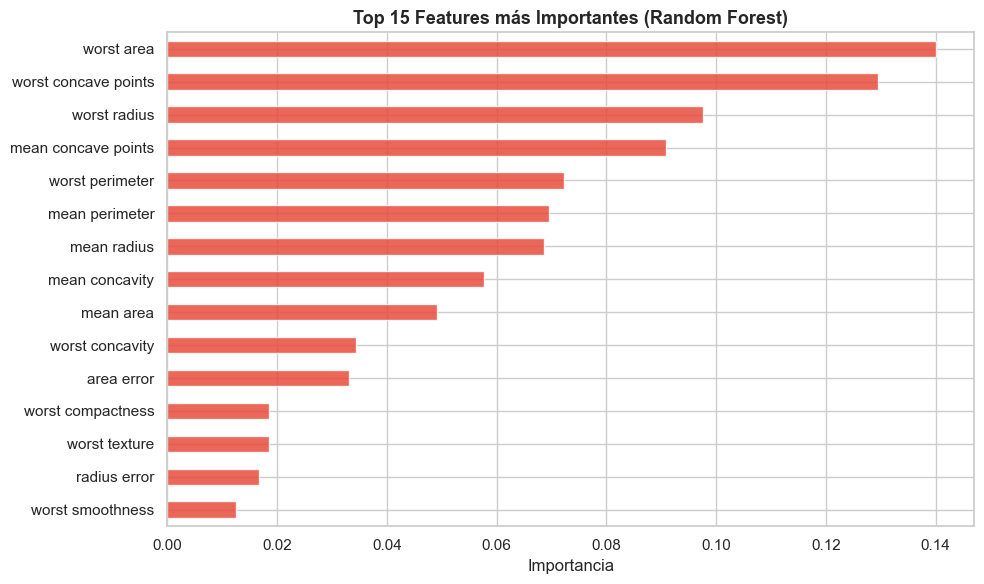

In [226]:
rf_model = trained_models['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names).nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Features más Importantes (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## 🏆 14. Resumen Ejecutivo y Conclusiones

In [227]:
best = results_df.iloc[0]
worst = results_df.iloc[-1]

print('=' * 60)
print(f'🥇 MEJOR MODELO  : {best["Modelo"]}')
print(f'   Accuracy      : {best["Accuracy"]:.3f}')
print(f'   F1 Macro      : {best["F1 (macro)"]:.3f}')
print(f'   AUC-ROC       : {best["AUC-ROC"]:.3f}')
print(f'   CV Mean       : {best["CV Mean"]:.3f} ± {best["CV Std"]:.3f}')
print('=' * 60)
print(f'\n🔻 MODELO MÁS BAJO: {worst["Modelo"]}')
print(f'   Accuracy      : {worst["Accuracy"]:.3f}')
print(f'   AUC-ROC       : {worst["AUC-ROC"]:.3f}')
print('=' * 60)
print('\n📊 RANKING COMPLETO:')
print(results_df[['Modelo','Accuracy','F1 (macro)','AUC-ROC','CV Mean']].to_string())

🥇 MEJOR MODELO  : Logistic Regression
   Accuracy      : 0.982
   F1 Macro      : 0.981
   AUC-ROC       : 0.995
   CV Mean       : 0.986 ± 0.009

🔻 MODELO MÁS BAJO: Decision Tree
   Accuracy      : 0.912
   AUC-ROC       : 0.916

📊 RANKING COMPLETO:
                Modelo  Accuracy  F1 (macro)   AUC-ROC   CV Mean
1  Logistic Regression  0.982456    0.981151  0.995370  0.985934
2                  SVM  0.982456    0.981151  0.995040  0.978916
3        Random Forest  0.956140    0.952638  0.993882  0.963080
4       MLP Neural Net  0.964912    0.962660  0.993717  0.973622
5    Gradient Boosting  0.956140    0.952129  0.990741  0.968343
6                  KNN  0.973684    0.971277  0.988426  0.968374
7          Naive Bayes  0.929825    0.924603  0.986772  0.929700
8        Decision Tree  0.912281    0.907468  0.915675  0.924406


## 💡 15. Guía de Decisión — ¿Qué modelo elegir?

| Situación | Modelo recomendado | Motivo |
|-----------|-------------------|--------|
| **Máxima precisión** | SVM / MLP Neural Net | Capturan fronteras de decisión complejas |
| **Interpretabilidad total** | Logistic Regression / Decision Tree | Puedes explicar cada predicción |
| **Balance precisión + robustez** | Random Forest / Gradient Boosting | Ensemble: menos overfitting |
| **Dataset muy pequeño (<100)** | Naive Bayes / KNN | Funcionan bien con pocos datos |
| **Prototipado rápido** | Logistic Regression | Entrena en milisegundos, buen baseline |
| **Diagnóstico médico** | SVM o RF con recall optimizado | Minimizar falsos negativos es crítico |

---

### ⚠️ Optimizar Recall en contexto médico: `class_weight` y threshold tuning

Hay dos formas principales de que el modelo priorice el Recall de la clase Maligno:

**Opción 1 — `class_weight='balanced'`** → se pone al **definir el modelo** (en la sección 4):  
Le dices al modelo que penalice más los errores en la clase minoritaria durante el entrenamiento.

```python
# En la sección 4, dentro del diccionario `models`:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM':                 SVC(probability=True, random_state=42, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),  # no tiene class_weight
    'KNN':                 KNeighborsClassifier(n_neighbors=7),           # no tiene class_weight
    'Naive Bayes':         GaussianNB(),                                  # no tiene class_weight
    'MLP Neural Net':      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),  # no tiene
}
# Para modelos sin class_weight, alternativa: usar resampleo (imblearn: SMOTE, RandomOverSampler)
```

**Opción 2 — Threshold tuning** → se aplica en la **predicción** (después de entrenar):  
En lugar del umbral 0.5 por defecto, lo bajas para detectar más Malignos aunque haya más falsas alarmas.

```python
# En la sección 5, dentro del bucle de entrenamiento, sustituye model.predict() por esto:
threshold = 0.3  # más sensible a Maligno (ajusta según necesidades)
y_pred = (model.predict_proba(X_test_s)[:, 0] >= threshold).astype(int)
# [:, 0] porque Maligno es la clase 0 en este dataset
```

> 💡 **Diferencia clave:** `class_weight` actúa durante el **entrenamiento** (cambia cómo aprende el modelo).  
> El threshold tuning actúa en la **predicción** (cambia cómo interpreta las probabilidades). Puedes combinar ambos.
